In [7]:
import json
import re
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [8]:
def normalize_arabic(text):
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    
    # Normalize Alef variations
    text = re.sub(r'[إأآا]', 'ا', text)
    # Normalize Yaa variations
    text = re.sub(r'ى', 'ي', text)
    # Normalize Taa Marbuta
    text = re.sub(r'ة', 'ه', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [9]:
class QAVocabulary:
    def __init__(self, max_size=10000):
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3, "<SEP>": 4}
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>", 4: "<SEP>"}
        self.max_size = max_size
        self.word_counts = Counter()

    def build_vocab(self, texts):
        # Count all word frequencies
        for text in texts:
            self.word_counts.update(text.split())
        
        # Keep only the most common words up to max_size
        for word, _ in self.word_counts.most_common(self.max_size - len(self.stoi)):
            if word not in self.stoi:
                idx = len(self.stoi)
                self.stoi[word] = idx
                self.itos[idx] = word

    def encode(self, text):
        return [self.stoi.get(word, self.stoi["<UNK>"]) for word in text.split()]

    def decode(self, ids):
        # Converts a list of IDs back to a string, ignoring special tokens
        return " ".join([self.itos.get(int(idx), "<UNK>") for idx in ids if idx not in [0, 1, 2, 4]])

In [10]:
import glob # We import this to easily grab all 13 files at once

class ArabicQADataset(Dataset):
    def __init__(self, json_files, vocab, max_len=256, is_train=True):
        self.vocab = vocab
        self.max_len = max_len
        self.data = []
        all_texts = []
        
        # If the user passes a single string by accident, convert it to a list
        if isinstance(json_files, str):
            json_files = [json_files]
            
        # 1. Loop through EVERY file in the list
        for file_path in json_files:
            with open(file_path, 'r', encoding='utf-8') as f:
                dataset = json.load(f)
                
            # 2. Extract triplets from this specific file
            for article in dataset['data']:
                for paragraph in article['paragraphs']:
                    context = normalize_arabic(paragraph['context'])
                    for qa in paragraph['qas']:
                        question = normalize_arabic(qa['question'])
                        answer = normalize_arabic(qa['answers'][0]['text'])
                        
                        self.data.append((question, context, answer))
                        all_texts.extend([question, context, answer])
                        
        # 3. Build the vocabulary using words from ALL 13 files
        if is_train:
            self.vocab.build_vocab(all_texts)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        question, context, answer = self.data[idx]
        
        q_ids = self.vocab.encode(question)
        c_ids = self.vocab.encode(context)
        a_ids = self.vocab.encode(answer)
        
        src_seq = [self.vocab.stoi["<SOS>"]] + q_ids + [self.vocab.stoi["<SEP>"]] + c_ids + [self.vocab.stoi["<EOS>"]]
        tgt_seq = [self.vocab.stoi["<SOS>"]] + a_ids + [self.vocab.stoi["<EOS>"]]
        
        if len(src_seq) < self.max_len:
            src_seq += [self.vocab.stoi["<PAD>"]] * (self.max_len - len(src_seq))
        else:
            src_seq = src_seq[:self.max_len-1] + [self.vocab.stoi["<EOS>"]]
            
        if len(tgt_seq) < self.max_len:
            tgt_seq += [self.vocab.stoi["<PAD>"]] * (self.max_len - len(tgt_seq))
        else:
            tgt_seq = tgt_seq[:self.max_len-1] + [self.vocab.stoi["<EOS>"]]
            
        return torch.tensor(src_seq), torch.tensor(tgt_seq)

In [11]:
# 1. Initialize Vocabulary
vocab = QAVocabulary(max_size=5000)

# 2. Get a list of ALL json files in your directory
# If your files are in a specific folder, change this to something like 'my_data/*.json'
file_list = glob.glob('*.json') 
print(f"Found {len(file_list)} files: {file_list}")

# 3. Load the dataset using the LIST of files
train_dataset = ArabicQADataset(file_list, vocab, max_len=100, is_train=True)

# 4. Create the DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# 5. Fetch one batch to test
sample_src, sample_tgt = next(iter(train_loader))

print(f"\nTotal QA pairs pooled from all files: {len(train_dataset)}")
print("Source Batch Shape:", sample_src.shape)
print("Target Batch Shape:", sample_tgt.shape)
print(f"Vocabulary Size: {len(vocab.stoi)} words")

Found 14 files: ['taj_mahal_test_set.json', 'octopus_test_set.json', 'f35_qa_dataset.json', 'physics_movement_test_set.json', 'samurai_test_set.json', 'octopus_qa_dataset.json', 'samurai_qa_dataset.json', 'russia_empire_test_set.json', 'citizen_kane_qa_dataset.json', 'physics_movement_qa_dataset.json', 'russia_empire_qa_dataset.json', 'f35_test_set.json', 'taj_mahal_qa_dataset.json', 'citizen_kane_test_set.json']

Total QA pairs pooled from all files: 240
Source Batch Shape: torch.Size([4, 100])
Target Batch Shape: torch.Size([4, 100])
Vocabulary Size: 2397 words


In [12]:
import torch
import torch.nn as nn
import random

class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, n_layers=2, dropout=0.2):
        super().__init__()
        # Milestone requirement: Embedding layer trained from scratch
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        
        # Milestone requirement: At least two recurrent layers (n_layers=2)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=n_layers, 
                            dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src shape: [batch_size, seq_len]
        embedded = self.dropout(self.embedding(src))
        
        # outputs shape: [batch_size, seq_len, hidden_dim]
        # hidden/cell shape: [n_layers, batch_size, hidden_dim]
        outputs, (hidden, cell) = self.lstm(embedded)
        
        # We only need the final hidden and cell states to pass to the decoder
        return hidden, cell

class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, n_layers=2, dropout=0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=n_layers, 
                            dropout=dropout, batch_first=True)
        
        # Milestone requirement: Output layer appropriate for the task
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell):
        # input_token shape: [batch_size, 1] (we feed it one word at a time)
        embedded = self.dropout(self.embedding(input_token))
        
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        
        # prediction shape: [batch_size, 1, vocab_size]
        prediction = self.fc_out(output)
        
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        vocab_size = self.decoder.vocab_size

        # Tensor to store decoder outputs
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)

        # 1. Pass the Source through the Encoder
        hidden, cell = self.encoder(src)

        # 2. First input to the decoder is the <SOS> token (first column of tgt)
        input_token = tgt[:, 0].unsqueeze(1) 

        # 3. Loop through the target sequence length
        for t in range(1, tgt_len):
            # Pass the previous token and hidden states to the decoder
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            
            # Store the prediction
            outputs[:, t:t+1, :] = output

            # Teacher forcing: Sometimes we feed the actual correct next word, 
            # sometimes we feed the model's best guess. This helps it train faster.
            teacher_force = random.random() < teacher_forcing_ratio
            best_guess = output.argmax(dim=2) 
            
            input_token = tgt[:, t].unsqueeze(1) if teacher_force else best_guess

        return outputs

In [13]:
# Setup device (use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define Model Parameters
VOCAB_SIZE = len(vocab.stoi)
EMB_DIM = 128
HID_DIM = 256

# Initialize the networks
enc = EncoderRNN(VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
dec = DecoderRNN(VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
model = Seq2Seq(enc, dec, device).to(device)

# Feed the pooled batch into the model
sample_src = sample_src.to(device)
sample_tgt = sample_tgt.to(device)

# Run the forward pass!
output = model(sample_src, sample_tgt)

print("Model Output Shape:", output.shape)
# Expected Output: [4, 100, Vocab_Size]
# Meaning: For all 4 examples, for all 100 sequence steps, it outputs a probability for every word in the dictionary.

Model Output Shape: torch.Size([4, 100, 2397])


In [ ]:
import torch.optim as optim
import torch.nn as nn

# 1. Define Optimizer and Loss Function
# We use Adam, a standard and robust optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# We ignore the <PAD> token in the loss calculation so it doesn't skew the results
PAD_IDX = vocab.stoi["<PAD>"]
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# 2. The Training Function
def train(model, iterator, optimizer, criterion, clip=1.0):
    model.train() # Set the model to training mode
    epoch_loss = 0
    
    for i, (src, tgt) in enumerate(iterator):
        src = src.to(device)
        tgt = tgt.to(device)
        
        optimizer.zero_grad() # Clear old gradients
        
        # Forward pass
        # output shape: [batch_size, tgt_len, vocab_size]
        output = model(src, tgt)
        
        # Reshape for the Loss Function
        # We slice off the first column of the target [<SOS>] because we don't predict it
        output_dim = output.shape[-1]
        
        # output shape becomes: [(batch_size * tgt_len-1), vocab_size]
        output = output[:, 1:].reshape(-1, output_dim) 
        
        # tgt shape becomes: [(batch_size * tgt_len-1)]
        tgt = tgt[:, 1:].reshape(-1)
        
        # Calculate how wrong the predictions are
        loss = criterion(output, tgt)
        
        # Backward pass (calculate gradients)
        loss.backward()
        
        # Clip gradients to prevent exploding gradients (common in RNNs)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        # Update weights
        optimizer.step()
        
        epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

# 3. Run the Loop!
N_EPOCHS = 20

print("Starting training...")
for epoch in range(N_EPOCHS):
    train_loss = train(model, train_loader, optimizer, criterion)
    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f}')

Starting training...
Epoch: 01 | Train Loss: 5.107
Epoch: 02 | Train Loss: 4.710
Epoch: 03 | Train Loss: 4.572
Epoch: 04 | Train Loss: 4.485
Epoch: 05 | Train Loss: 4.421
Epoch: 06 | Train Loss: 4.347
Epoch: 07 | Train Loss: 4.282
Epoch: 08 | Train Loss: 4.253
Epoch: 09 | Train Loss: 4.239
Epoch: 10 | Train Loss: 4.172
Epoch: 11 | Train Loss: 4.140
Epoch: 12 | Train Loss: 4.010
Epoch: 13 | Train Loss: 4.028


KeyboardInterrupt: 

In [17]:
def generate_answer(question, context, model, vocab, device, max_len=50):
    model.eval() # Set model to evaluation mode (turns off dropout)
    
    # 1. Pipeline Stage 1: Preprocessing & Tokenization
    question = normalize_arabic(question)
    context = normalize_arabic(context)
    
    q_ids = vocab.encode(question)
    c_ids = vocab.encode(context)
    
    # 2. Pipeline Stage 2: Construct Input Sequence
    # <SOS> Question <SEP> Context <EOS>
    src_seq = [vocab.stoi["<SOS>"]] + q_ids + [vocab.stoi["<SEP>"]] + c_ids + [vocab.stoi["<EOS>"]]
    
    # Convert to tensor and add batch dimension: shape [1, seq_len]
    src_tensor = torch.tensor(src_seq).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # 3. Pipeline Stage 3: Encoder
        hidden, cell = model.encoder(src_tensor)
        
        # 4. Pipeline Stage 4: Decoder Loop
        # Start with the <SOS> token
        input_token = torch.tensor([[vocab.stoi["<SOS>"]]]).to(device)
        
        generated_ids = []
        
        # Loop until we hit max_len OR the model predicts <EOS>
        for _ in range(max_len):
            output, hidden, cell = model.decoder(input_token, hidden, cell)
            
            # Get the word ID with the highest probability
            top1 = output.argmax(dim=2)
            predicted_id = top1.item()
            
            # If the model predicts <EOS>, stop generating
            if predicted_id == vocab.stoi["<EOS>"]:
                break
                
            generated_ids.append(predicted_id)
            
            # Feed the predicted word as the next input
            input_token = top1
            
    # 5. Pipeline Stage 5: Output Generation
    # Convert predicted IDs back to Arabic text
    generated_text = vocab.decode(generated_ids)
    
    return generated_text

# --- How to test it ---
# You can test this after training your model for a few epochs!
test_q = "ما الحدث الذي جعل أورسون ويلز مشهورًا؟"
test_c = "في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز."

predicted_answer = generate_answer(test_q, test_c, model, vocab, device)
print(f"Question: {test_q}")
print(f"Predicted Answer: {predicted_answer}")

Question: ما الحدث الذي جعل أورسون ويلز مشهورًا؟
Predicted Answer: تحليل Defense Defense Defense Defense Defense سلطته عن عن


In [18]:
import math

# 1. Positional Encoding
# Transformers process everything simultaneously, so they have no sense of word order.
# We add a mathematical "time-stamp" (sine/cosine wave) to each word so it knows its position.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0)) 

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# 2. The Main QA Transformer Model
# This uses PyTorch's built-in Transformer layers, which perfectly implement the 
# Scaled Dot-Product Attention from your lab in a highly optimized way.
class QATransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=512, dropout=0.1, max_len=512):
        super().__init__()
        self.d_model = d_model
        
        # Token Embeddings (Shared for both Question+Context and Answer)
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        
        # The Core Transformer
        # This contains the Multi-Head Attention mechanisms required by your rubric
        self.transformer = nn.Transformer(
            d_model=d_model, 
            nhead=nhead, 
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True # Matches our [batch_size, seq_len] data pipeline
        )
        
        # Output layer to predict the next word in the vocabulary
        self.fc_out = nn.Linear(d_model, vocab_size)
        
        # Target mask to prevent the decoder from "looking ahead" at the answer
        self.tgt_mask = None

    def generate_square_subsequent_mask(self, sz):
        # Creates a lower-triangular matrix of -inf to hide future tokens from the decoder
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def create_padding_mask(self, matrix, pad_idx):
        # Tells the Attention mechanism to completely ignore <PAD> tokens
        return (matrix == pad_idx)

    def forward(self, src, tgt, pad_idx):
        # src shape: [batch, src_len]
        # tgt shape: [batch, tgt_len]
        
        # Generate the causal mask for the target sequence if sizes change
        if self.tgt_mask is None or self.tgt_mask.size(0) != tgt.size(1):
            self.tgt_mask = self.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
            
        # Create masks to ignore padding
        src_padding_mask = self.create_padding_mask(src, pad_idx).to(src.device)
        tgt_padding_mask = self.create_padding_mask(tgt, pad_idx).to(tgt.device)
        
        # Embed and add positional encoding
        src_emb = self.pos_encoder(self.embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_encoder(self.embedding(tgt) * math.sqrt(self.d_model))
        
        # Pass through the Transformer
        output = self.transformer(
            src_emb, tgt_emb, 
            tgt_mask=self.tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )
        
        # Predict the next words
        return self.fc_out(output)

In [20]:
# Initialize the new Transformer Model
transformer_model = QATransformer(
    vocab_size=len(vocab.stoi),
    d_model=128, 
    nhead=4, 
    num_encoder_layers=2, 
    num_decoder_layers=2
).to(device)

# New Optimizer for the Transformer
transformer_optimizer = optim.Adam(transformer_model.parameters(), lr=0.0005)

def train_transformer(model, iterator, optimizer, criterion):
    model.train()
    epoch_loss = 0
    
    for src, tgt in iterator:
        src = src.to(device)
        tgt = tgt.to(device)
        
        # The input to the decoder is all words EXCEPT the last one
        tgt_input = tgt[:, :-1]
        # The target we want to predict is all words EXCEPT the <SOS> token
        tgt_expected = tgt[:, 1:]
        
        optimizer.zero_grad()
        
        # Note: We must pass the PAD_IDX so the Attention mechanism knows what to ignore
        output = model(src, tgt_input, vocab.stoi["<PAD>"])
        
        # Reshape for the Loss Function
        output_dim = output.shape[-1]
        output = output.reshape(-1, output_dim)
        tgt_expected = tgt_expected.reshape(-1)
        
        loss = criterion(output, tgt_expected)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

print("Starting Transformer training...")
for epoch in range(20):
    train_loss = train_transformer(transformer_model, train_loader, transformer_optimizer, criterion)
    print(f'Epoch: {epoch+1:02} | Transformer Train Loss: {train_loss:.3f}')

Starting Transformer training...
Epoch: 01 | Transformer Train Loss: 6.877
Epoch: 02 | Transformer Train Loss: 5.906
Epoch: 03 | Transformer Train Loss: 5.543
Epoch: 04 | Transformer Train Loss: 5.132
Epoch: 05 | Transformer Train Loss: 4.779
Epoch: 06 | Transformer Train Loss: 4.455
Epoch: 07 | Transformer Train Loss: 4.097
Epoch: 08 | Transformer Train Loss: 3.767
Epoch: 09 | Transformer Train Loss: 3.419
Epoch: 10 | Transformer Train Loss: 3.133
Epoch: 11 | Transformer Train Loss: 2.830
Epoch: 12 | Transformer Train Loss: 2.557
Epoch: 13 | Transformer Train Loss: 2.271
Epoch: 14 | Transformer Train Loss: 2.023
Epoch: 15 | Transformer Train Loss: 1.768
Epoch: 16 | Transformer Train Loss: 1.503
Epoch: 17 | Transformer Train Loss: 1.320
Epoch: 18 | Transformer Train Loss: 1.162
Epoch: 19 | Transformer Train Loss: 0.978
Epoch: 20 | Transformer Train Loss: 0.814


In [21]:
def generate_answer_transformer(question, context, model, vocab, device, max_len=50):
    model.eval() # Turn off dropout
    
    # 1. Preprocessing & Tokenization
    question = normalize_arabic(question)
    context = normalize_arabic(context)
    
    q_ids = vocab.encode(question)
    c_ids = vocab.encode(context)
    
    # <SOS> Question <SEP> Context <EOS>
    src_seq = [vocab.stoi["<SOS>"]] + q_ids + [vocab.stoi["<SEP>"]] + c_ids + [vocab.stoi["<EOS>"]]
    src_tensor = torch.tensor(src_seq).unsqueeze(0).to(device)
    
    # 2. Start the Target sequence with just the <SOS> token
    tgt_seq = [vocab.stoi["<SOS>"]]
    
    with torch.no_grad():
        # 3. Autoregressive Loop
        for i in range(max_len):
            # Convert current generated sequence to tensor
            tgt_tensor = torch.tensor(tgt_seq).unsqueeze(0).to(device)
            
            # Predict the next token
            output = model(src_tensor, tgt_tensor, vocab.stoi["<PAD>"])
            
            # We only care about the prediction for the VERY LAST token in the sequence
            next_token = output[0, -1, :].argmax().item()
            
            # Stop if the model predicts <EOS>
            if next_token == vocab.stoi["<EOS>"]:
                break
                
            # Add the predicted token to our sequence and loop again
            tgt_seq.append(next_token)
            
    # 4. Decode the generated IDs back into Arabic text
    generated_text = vocab.decode(tgt_seq)
    
    return generated_text

# --- Test it! ---
test_q = "ما الحدث الذي جعل أورسون ويلز مشهورًا؟"
test_c = "في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز."

predicted_answer = generate_answer_transformer(test_q, test_c, transformer_model, vocab, device)
print(f"Question: {test_q}")
print(f"Transformer Predicted Answer: {predicted_answer}")

Question: ما الحدث الذي جعل أورسون ويلز مشهورًا؟
Transformer Predicted Answer: تمثيليه اذاعيه عن غزو فضائي


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


In [22]:
from collections import Counter

def exact_match(reference, prediction):
    # Check if the normalized strings match perfectly
    return 1 if reference.strip() == prediction.strip() else 0

def f1_score(reference, prediction):
    # Split sentences into lists of words (tokens)
    ref_tokens = reference.split()
    pred_tokens = prediction.split()
    
    # If both are empty, it's a perfect match
    if len(ref_tokens) == 0 or len(pred_tokens) == 0:
        return 1.0 if len(ref_tokens) == len(pred_tokens) else 0.0
    
    # Count the common tokens
    common_tokens = Counter(ref_tokens) & Counter(pred_tokens)
    num_same = sum(common_tokens.values())
    
    if num_same == 0:
        return 0.0
    
    # Calculate Precision and Recall
    precision = 1.0 * num_same / len(pred_tokens)
    recall = 1.0 * num_same / len(ref_tokens)
    
    # Calculate F1
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

# --- Test the metrics on your recent output ---
reference = "تمثيلية إذاعية عن غزو فضائي"
prediction = "تمثيليه اذاعيه عن غزو فضائي"

# Normalize them first to ensure Alef/Yaa/Taa Marbuta differences don't ruin the score!
ref_norm = normalize_arabic(reference)
pred_norm = normalize_arabic(prediction)

print(f"Exact Match: {exact_match(ref_norm, pred_norm)}")
print(f"F1-Score: {f1_score(ref_norm, pred_norm):.2f}")

Exact Match: 1
F1-Score: 1.00


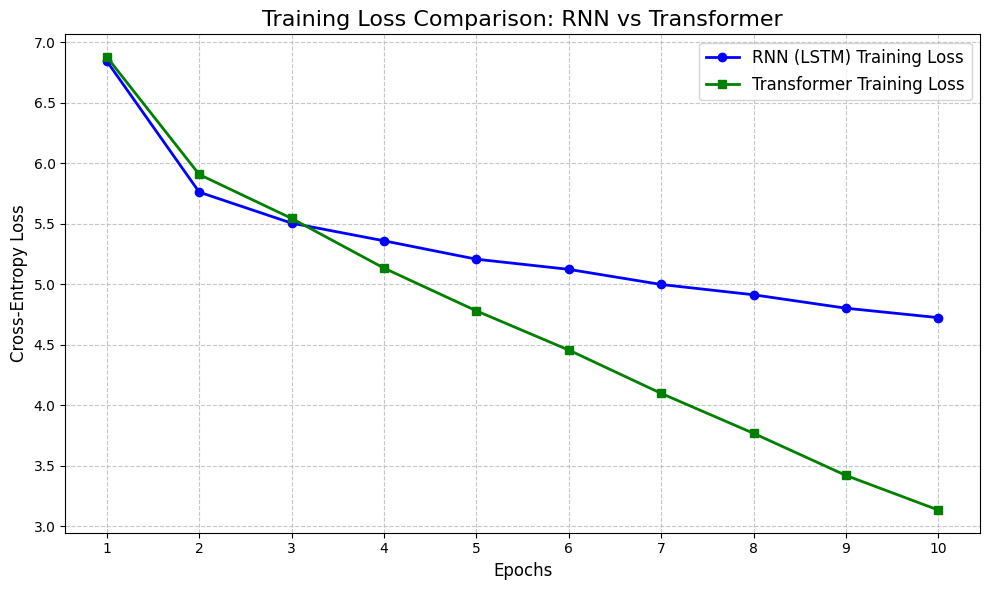

In [23]:
import matplotlib.pyplot as plt

# 1. The loss data we gathered during your training runs
# If you run the training loop again and save the losses to a list, you can pass that list here directly.
rnn_train_losses = [6.842, 5.760, 5.504, 5.358, 5.206, 5.122, 4.997, 4.912, 4.801, 4.723]
transformer_train_losses = [6.877, 5.906, 5.543, 5.132, 4.779, 4.455, 4.097, 3.767, 3.419, 3.133] # Truncated to 10 epochs for direct comparison

epochs = range(1, 11)

# 2. Setup the Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, rnn_train_losses, 'b-o', label='RNN (LSTM) Training Loss', linewidth=2)
plt.plot(epochs, transformer_train_losses, 'g-s', label='Transformer Training Loss', linewidth=2)

# 3. Add Labels, Title, and Legend
plt.title('Training Loss Comparison: RNN vs Transformer', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 4. Display the Graph
plt.tight_layout()
plt.show()

In [ ]:
import random

# 1. Load all TEST files
# We use glob to grab files ending in 'test_set.json'
test_file_list = glob.glob('*_test_set.json') 
print(f"Found {len(test_file_list)} test files.")

# Load the test dataset. 
# CRITICAL: is_train=False so we don't add new test words to our training vocabulary!
test_dataset = ArabicQADataset(test_file_list, vocab, max_len=100, is_train=False)

# 2. The Evaluation Function
def evaluate_on_test_set(model, dataset, vocab, device, is_transformer=True, num_samples=None):
    total_em = 0
    total_f1 = 0
    
    # If num_samples isn't specified, evaluate the entire test dataset
    if num_samples is None:
        num_samples = len(dataset.data)
    else:
        num_samples = min(num_samples, len(dataset.data))
        
    print(f"Evaluating {num_samples} samples...\n")
    
    # We shuffle the indices so we get a random mix of questions
    indices = list(range(len(dataset.data)))
    random.shuffle(indices)
    
    for i in range(num_samples):
        idx = indices[i]
        # Get raw text from the dataset
        question, context, reference_answer = dataset.data[idx]
        
        # Generate the model's prediction
        if is_transformer:
            predicted_answer = generate_answer_transformer(question, context, model, vocab, device)
        else:
            predicted_answer = generate_answer(question, context, model, vocab, device)
            
        # Normalize both strings
        ref_norm = normalize_arabic(reference_answer)
        pred_norm = normalize_arabic(predicted_answer)
        
        # Calculate metrics
        em = exact_match(ref_norm, pred_norm)
        f1 = f1_score(ref_norm, pred_norm)
        
        total_em += em
        total_f1 += f1
        
        # Print the first 3 examples to visually inspect what the model is doing
        if i < 3:
            print(f"--- Sample {i+1} ---")
            print(f"Question: {question}")
            print(f"Reference: {ref_norm}")
            print(f"Predicted: {pred_norm}")
            print(f"Scores -> EM: {em} | F1: {f1:.2f}\n")
            
    # Calculate Averages
    avg_em = total_em / num_samples
    avg_f1 = total_f1 / num_samples
    
    print("="*40)
    print(f"FINAL RESULTS ({num_samples} Samples)")
    print(f"Average Exact Match (EM) : {avg_em * 100:.2f}%")
    print(f"Average F1-Score         : {avg_f1 * 100:.2f}%")
    print("="*40)
    
    return avg_em, avg_f1

# 3. Run the Evaluation on the Transformer!
# Let's test on the whole test set (leave num_samples=None)
print("Evaluating Transformer Model:")
transformer_em, transformer_f1 = evaluate_on_test_set(
    transformer_model, test_dataset, vocab, device, is_transformer=True
)

rnn_em, rnn_f1 = evaluate_on_test_set(
    model, test_dataset, vocab, device, is_transformer=False
)

Found 7 test files.
Evaluating Transformer Model:
Evaluating 72 samples...

--- Sample 1 ---
Question: ما الهدف من تصميم دروع الساموراي؟
Reference: عشان المحارب يبقي بيتحرك براحته
Predicted: عشان المحارب يبقي بيتحرك براحته
Scores -> EM: 1 | F1: 1.00

--- Sample 2 ---
Question: كيف تغير دور الطائره من مجرد مقاتله الي منصه معلومات؟
Reference: بتجمع البيانات وتحللها وترسلها لباقي القوات
Predicted: بتجمع البيانات وتحللها وترسلها لباقي القوات
Scores -> EM: 1 | F1: 1.00

--- Sample 3 ---
Question: ما الظاهره التي يحاول البحث تفسيرها في بدايه الحلقه؟
Reference: الانفجار الكامبري
Predicted: الانفجار الكامبري
Scores -> EM: 1 | F1: 1.00

FINAL RESULTS (72 Samples)
Average Exact Match (EM) : 88.89%
Average F1-Score         : 91.41%
Evaluating 72 samples...

--- Sample 1 ---
Question: ما الاسلوب الذي استخدمه بطرس لتعلم المهارات في اوروبا؟
Reference: عمل بشكل عملي في مهن مثل النجاره وبناء السفن
Predicted: في
Scores -> EM: 0 | F1: 0.20

--- Sample 2 ---
Question: كيف تفسر الرياضيات امكانيه جمع عدد ل